# 2. 데이터 시각화

가장 기초적인 히스토그램, 산점도부터 boxplot, 막대그래프, 파이차트 등 다양한 그래프를 그려보고, 시각화를 위해 스타일을 변경해볼 것입니다.

제작자 : Jaeseung Lee, Junhyeck Choi

## 2.1 matplotlib을 활용한 데이터 시각화

matplotlib는 파이썬의 대표적인 데이터 플로팅 라이브러리입니다. 기본 막대형 그래프부터 3차원 그래프, Tree map등 다양한 그래프 플로팅을 지원합니다.


<img src="https://miro.medium.com/max/9450/1*OAFEIg9w1XHyZk0xBud14A.png" width="600" height="600" />

seaborn은 Matplotlib을 기반으로 다양한 색상 테마, 통계용 차트 등의 기능을 추가한 시각화 패키지로 마찬가지로 활용도가 높습니다.\
아래 코드들은 기본적으로 실행시켜주세요~

In [ ]:
# 한글깨지는것 방지하기 위해 koreanize-matplotlib 사용
# %pip install koreanize-matplotlib


Note: you may need to restart the kernel to use updated packages.


In [3]:
import matplotlib.pyplot as plt
import setuptools  # Python 3.12+ removed distutils; setuptools provides a shim that koreanize_matplotlib needs
import koreanize_matplotlib

import numpy as np
import pandas as pd

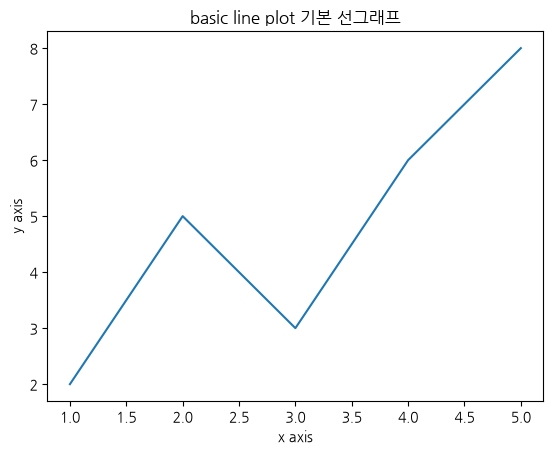

In [6]:
# basic line plot
x = np.array([1, 2, 3, 4, 5])
y = np.array([2, 5, 3, 6, 8])
plt.plot(x,y)
plt.xlabel('x axis')
plt.ylabel('y axis')
plt.title('basic line plot 기본 선그래프')
plt.show()

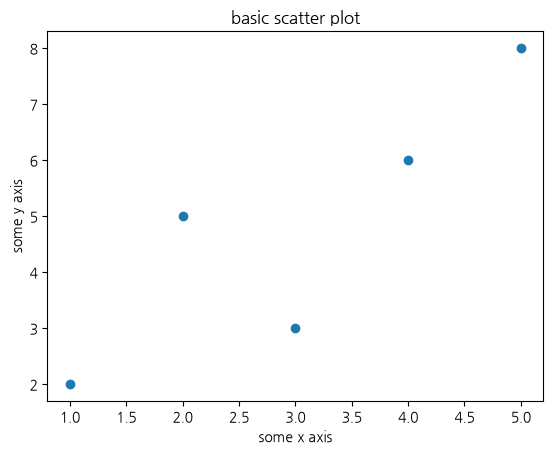

In [7]:
# basic scatter plot
x = np.array([1, 2, 3, 4, 5])
y = np.array([2, 5, 3, 6, 8])
plt.scatter(x,y)
plt.xlabel('some x axis')
plt.ylabel('some y axis')
plt.title('basic scatter plot')
plt.show()

## 1. Histogram
Purpose: Showing the distribution of a numerical variable

In [8]:
# Example data: Drinks data
drink_cols = ['country', 'beer', 'spirit', 'wine', 'pure', 'continent']
url = 'https://raw.githubusercontent.com/justmarkham/DAT8/master/data/drinks.csv'
drinks = pd.read_csv(url, header=0, names=drink_cols, na_filter=False)
drinks

,country,beer,spirit,wine,pure,continent
0,Afghanistan,0,0,0,0.0,AS
1,Albania,89,132,54,4.9,EU
2,Algeria,25,0,14,0.7,AF
3,Andorra,245,138,312,12.4,EU
4,Angola,217,57,45,5.9,AF
...,...,...,...,...,...,...
188,Venezuela,333,100,3,7.7,SA
189,Vietnam,111,2,1,2.0,AS
190,Yemen,6,0,0,0.1,AS
191,Zambia,32,19,4,2.5,AF


In [9]:
# sort the beer column 
drinks.beer.sort_values(ascending=True)

0        0
13       0
40       0
46       0
111      0
      ... 
98     343
65     346
62     347
45     361
117    376
Name: beer, Length: 193, dtype: int64

<Axes: ylabel='Frequency'>

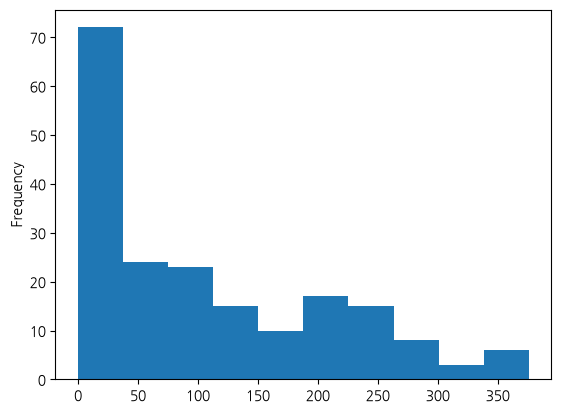

In [10]:
# compare with histogram
drinks.beer.plot(kind='hist', bins=10)

Text(0.5, 1.0, 'Histogram of Beer Servings')

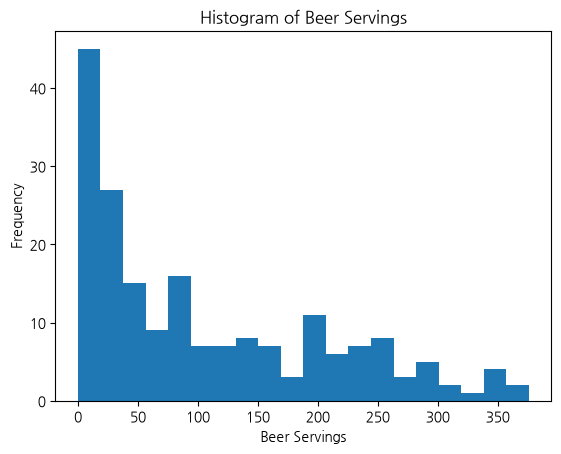

In [11]:
# try more bins
# add title and labels
drinks.beer.plot(kind='hist', bins=20)
plt.xlabel('Beer Servings')
plt.ylabel('Frequency')
plt.title('Histogram of Beer Servings')

<Axes: ylabel='Density'>

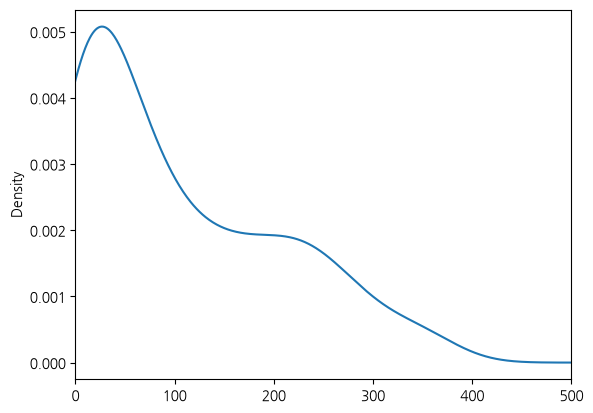

In [12]:
# compare with density plot (smooth version of a histogram)
drinks.beer.plot(kind='density', xlim=(0, 500))

array([[<Axes: title={'center': 'beer'}>]], dtype=object)

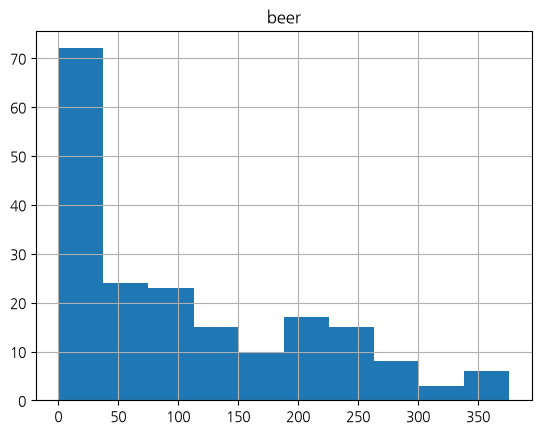

In [13]:
drinks.hist(column='beer')

array([[<Axes: title={'center': 'AF'}>, <Axes: title={'center': 'AS'}>],
       [<Axes: title={'center': 'EU'}>, <Axes: title={'center': 'NA'}>],
       [<Axes: title={'center': 'OC'}>, <Axes: title={'center': 'SA'}>]],
      dtype=object)

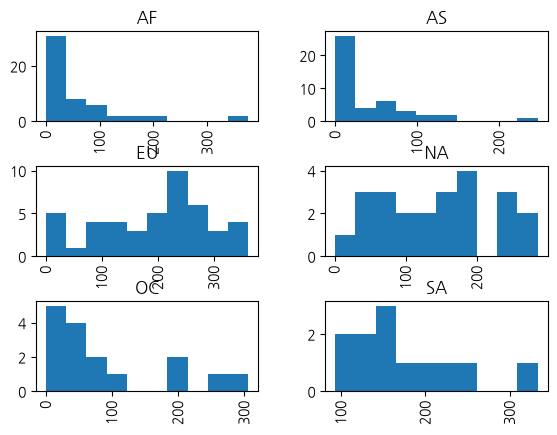

In [14]:
# histogram of beer servings grouped by continent
drinks.hist(column='beer', by='continent')

array([[<Axes: title={'center': 'AF'}>, <Axes: title={'center': 'AS'}>],
       [<Axes: title={'center': 'EU'}>, <Axes: title={'center': 'NA'}>],
       [<Axes: title={'center': 'OC'}>, <Axes: title={'center': 'SA'}>]],
      dtype=object)

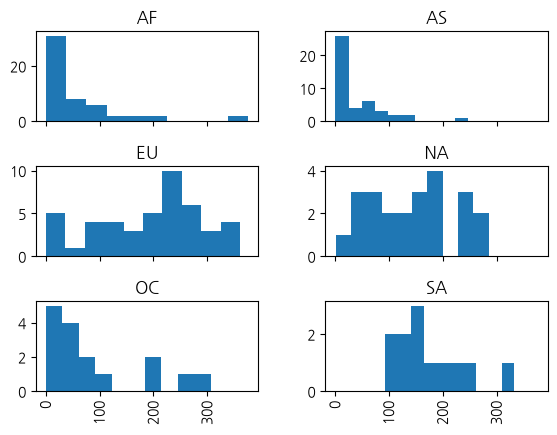

In [15]:
# share the x axes
drinks.hist(column='beer', by='continent', sharex=True)

array([[<Axes: title={'center': 'AF'}>, <Axes: title={'center': 'AS'}>],
       [<Axes: title={'center': 'EU'}>, <Axes: title={'center': 'NA'}>],
       [<Axes: title={'center': 'OC'}>, <Axes: title={'center': 'SA'}>]],
      dtype=object)

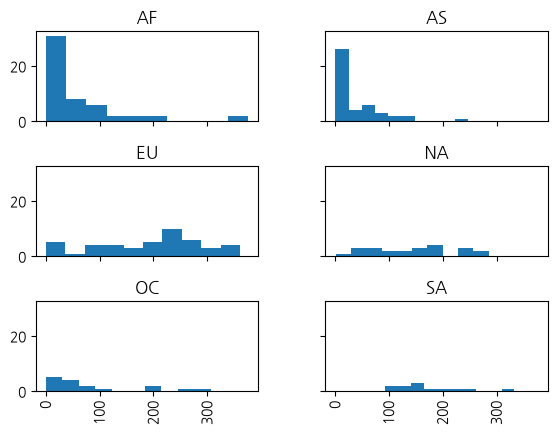

In [16]:
# share the x and y axes
drinks.hist(column='beer', by='continent', sharex=True, sharey=True)

array([[<Axes: title={'center': 'AF'}>, <Axes: title={'center': 'AS'}>,
        <Axes: title={'center': 'EU'}>],
       [<Axes: title={'center': 'NA'}>, <Axes: title={'center': 'OC'}>,
        <Axes: title={'center': 'SA'}>]], dtype=object)

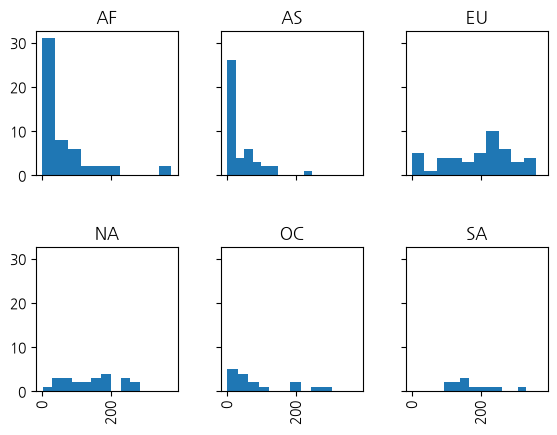

In [17]:
# change the layout
drinks.hist(column='beer', by='continent', sharex=True, sharey=True, layout=(2, 3))

## 2. Scatter plot
Purpose: Showing the relationship between two numerical variables

In [18]:
# select the beer and wine columns and sort by beer
drinks[['beer', 'wine']].sort_values(by='beer')

,beer,wine
0,0,0
13,0,0
40,0,74
46,0,0
111,0,0
...,...,...
98,343,56
65,346,175
62,347,59
45,361,134


<Axes: xlabel='beer', ylabel='wine'>

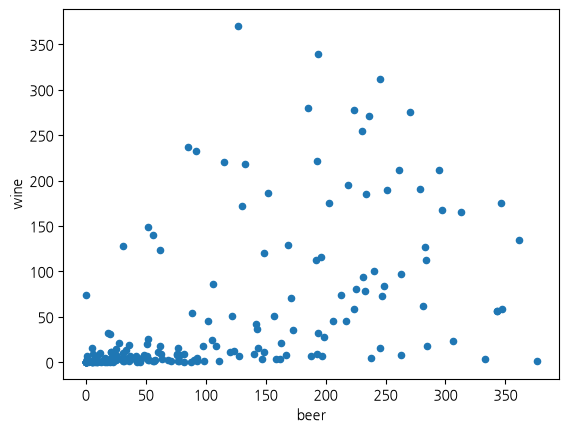

In [19]:
# compare with scatter plot
drinks.plot(kind='scatter', x='beer', y='wine')

<Axes: xlabel='beer', ylabel='wine'>

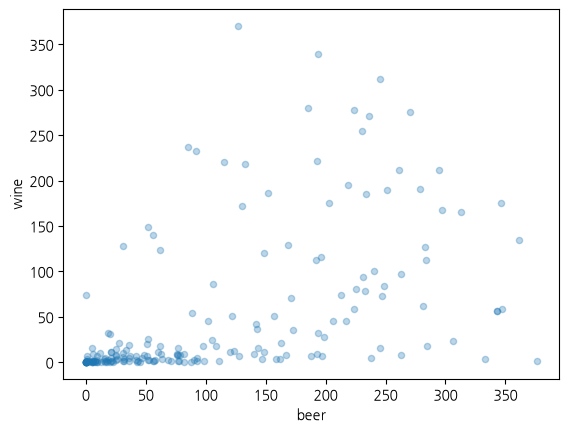

In [20]:
# add transparency
drinks.plot(kind='scatter', x='beer', y='wine', alpha=0.3)

<Axes: xlabel='beer', ylabel='wine'>

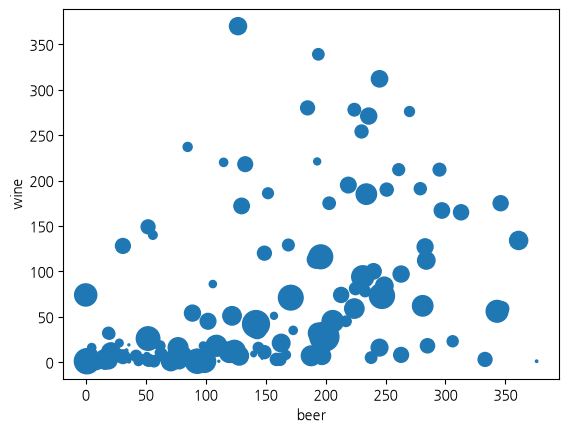

In [21]:
# vary point size by spirit servings
drinks.plot(kind='scatter', x='beer', y='wine', s='spirit')

## Matplotlib Color Maps
https://matplotlib.org/stable/tutorials/colors/colormaps.html

<Axes: xlabel='beer', ylabel='wine'>

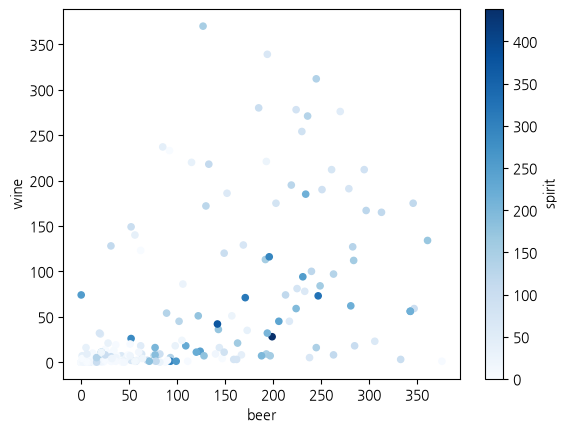

In [22]:
# vary point color by spirit servings
drinks.plot(kind='scatter', x='beer', y='wine', c='spirit', colormap='Blues')

<Axes: xlabel='beer', ylabel='wine'>

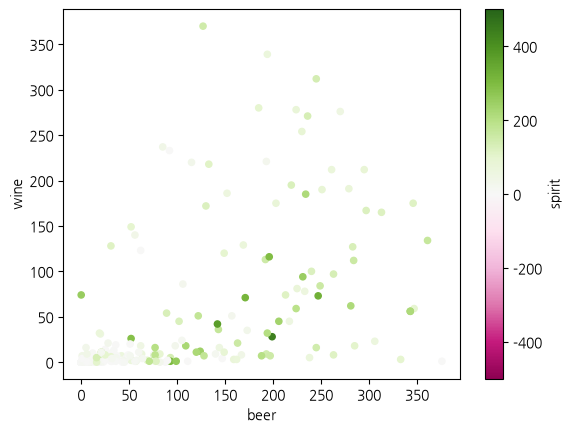

In [23]:
drinks.plot(kind='scatter', x='beer', y='wine', c='spirit', colormap='PiYG', vmin=-500, vmax=500)

array([[<Axes: xlabel='beer', ylabel='beer'>,
        <Axes: xlabel='spirit', ylabel='beer'>,
        <Axes: xlabel='wine', ylabel='beer'>],
       [<Axes: xlabel='beer', ylabel='spirit'>,
        <Axes: xlabel='spirit', ylabel='spirit'>,
        <Axes: xlabel='wine', ylabel='spirit'>],
       [<Axes: xlabel='beer', ylabel='wine'>,
        <Axes: xlabel='spirit', ylabel='wine'>,
        <Axes: xlabel='wine', ylabel='wine'>]], dtype=object)

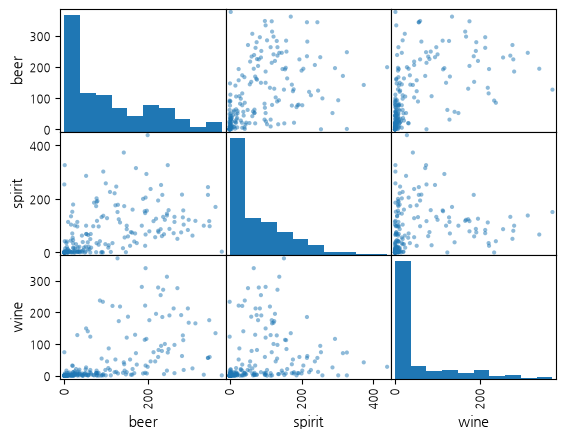

In [24]:
# scatter matrix of three numerical columns
pd.plotting.scatter_matrix(drinks[['beer', 'spirit', 'wine']])

array([[<Axes: xlabel='beer', ylabel='beer'>,
        <Axes: xlabel='spirit', ylabel='beer'>,
        <Axes: xlabel='wine', ylabel='beer'>],
       [<Axes: xlabel='beer', ylabel='spirit'>,
        <Axes: xlabel='spirit', ylabel='spirit'>,
        <Axes: xlabel='wine', ylabel='spirit'>],
       [<Axes: xlabel='beer', ylabel='wine'>,
        <Axes: xlabel='spirit', ylabel='wine'>,
        <Axes: xlabel='wine', ylabel='wine'>]], dtype=object)

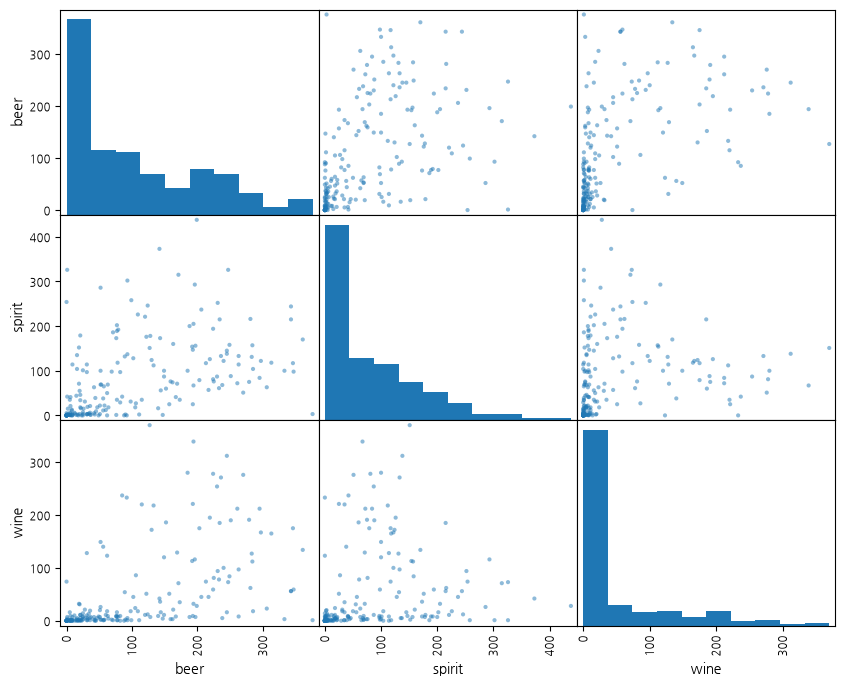

In [25]:
# increase figure size
pd.plotting.scatter_matrix(drinks[['beer', 'spirit', 'wine']], figsize=(10, 8))

## 3. Bar plot
Purpose: Showing a numerical comparison across different categories

In [26]:
# count the number of countries in each continent
drinks.continent.value_counts()

continent
AF    53
EU    45
AS    44
NA    23
OC    16
SA    12
Name: count, dtype: int64

<Axes: xlabel='continent'>

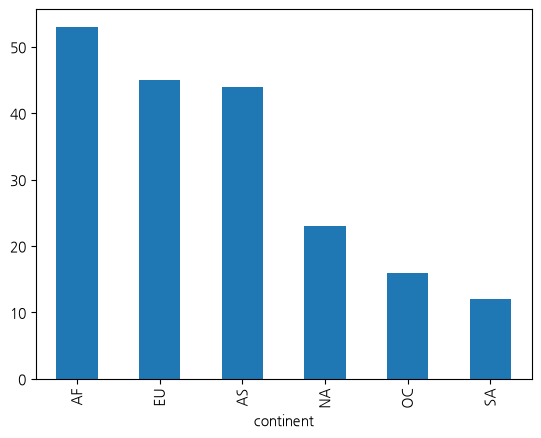

In [27]:
# compare with bar plot
drinks.continent.value_counts().plot(kind='bar')

In [28]:
# calculate the mean alcohol amounts for each continent
drink_continent=drinks.groupby(['continent'])[['beer','spirit','wine','pure']].agg(['mean']).droplevel(axis=1,level=1).reset_index()
drink_continent

,continent,beer,spirit,wine,pure
0,AF,61.471698,16.339623,16.264151,3.007547
1,AS,37.045455,60.840909,9.068182,2.170455
2,EU,193.777778,132.555556,142.222222,8.617778
3,NA,145.434783,165.739130,24.521739,5.995652
4,OC,89.687500,58.437500,35.625000,3.381250
5,SA,175.083333,114.750000,62.416667,6.308333


<Axes: >

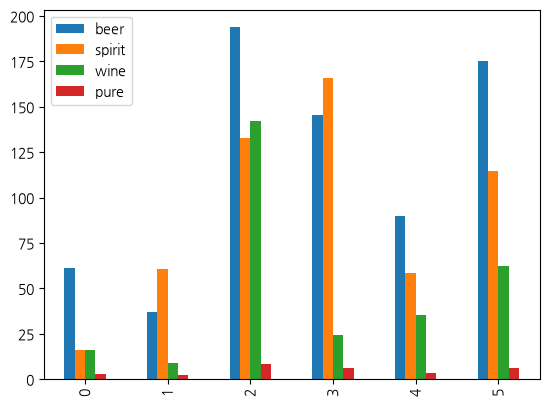

In [29]:
# side-by-side bar plots
drink_continent.plot(kind='bar')

<Axes: >

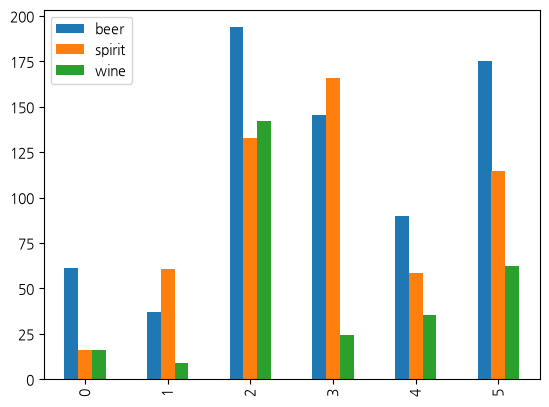

In [30]:
# drop the liters column
drink_continent.drop('pure', axis=1).plot(kind='bar')

<Axes: >

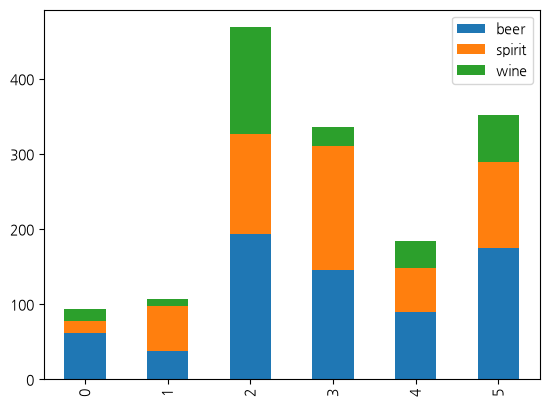

In [31]:
# stacked bar plots
drink_continent.drop('pure', axis=1).plot(kind='bar', stacked=True)

## 4. Box plot
Purpose: Showing quartiles and outliers for one or more numerical variables

**Five-number summary:**

- min = minimum value
- 25% = first quartile (Q1) = median of the lower half of the data
- 50% = second quartile (Q2) = median of the data
- 75% = third quartile (Q3) = median of the upper half of the data
- max = maximum value

(More useful than mean and standard deviation for describing skewed distributions)

**Interquartile Range (IQR)** = Q3 - Q1

**Outliers:**

- below Q1 - 1.5 * IQR
- above Q3 + 1.5 * IQR

In [32]:
# sort the spirit column
drinks.spirit.sort_values(ascending=True)

0        0
2        0
13       0
19       0
27       0
      ... 
144    315
141    326
73     326
15     373
68     438
Name: spirit, Length: 193, dtype: int64

In [33]:
# show "five-number summary" for spirit
drinks.spirit.describe()

count    193.000000
mean      80.994819
std       88.284312
min        0.000000
25%        4.000000
50%       56.000000
75%      128.000000
max      438.000000
Name: spirit, dtype: float64

<Axes: >

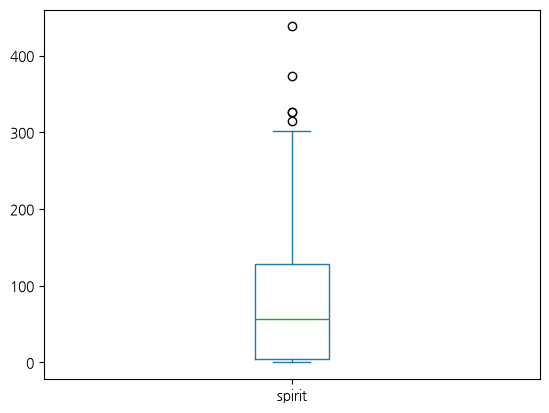

In [34]:
# compare with box plot
drinks.spirit.plot(kind='box')

<Axes: >

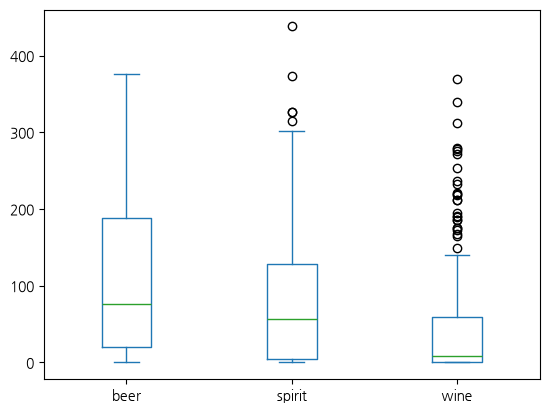

In [35]:
# include multiple variables
drinks.drop('pure', axis=1).plot(kind='box')

<Axes: title={'center': 'beer'}, xlabel='continent'>

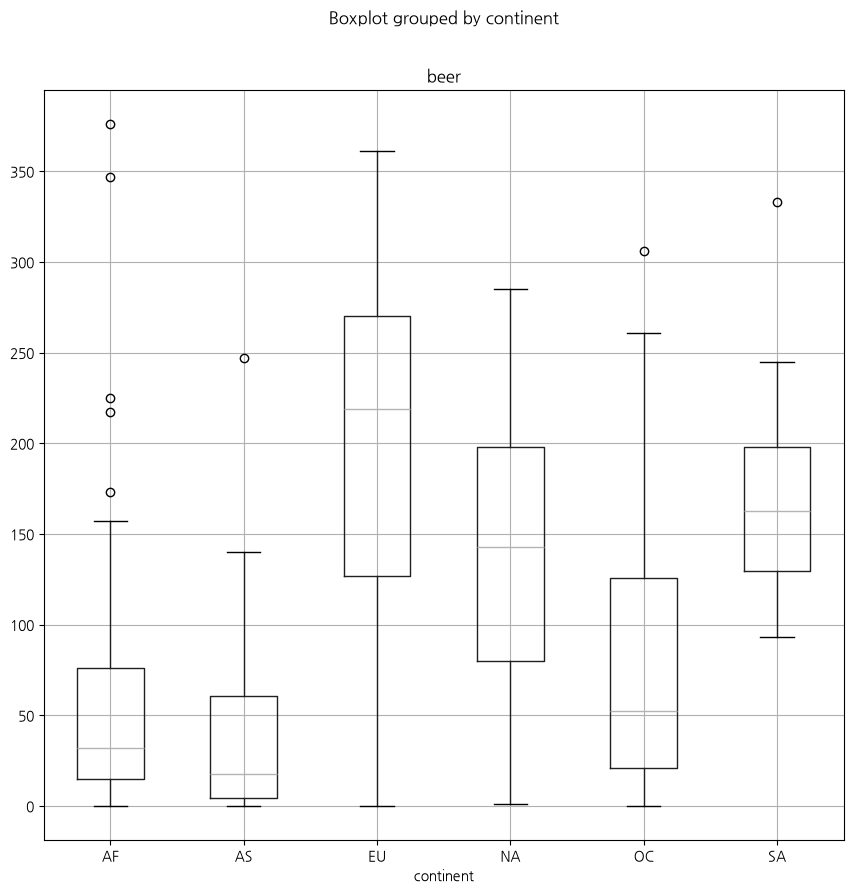

In [36]:
# box plot of beer servings grouped by continent
drinks.boxplot(column='beer', by='continent', figsize=(10, 10))

array([[<Axes: title={'center': 'beer'}, xlabel='[continent]'>,
        <Axes: title={'center': 'pure'}, xlabel='[continent]'>],
       [<Axes: title={'center': 'spirit'}, xlabel='[continent]'>,
        <Axes: title={'center': 'wine'}, xlabel='[continent]'>]],
      dtype=object)

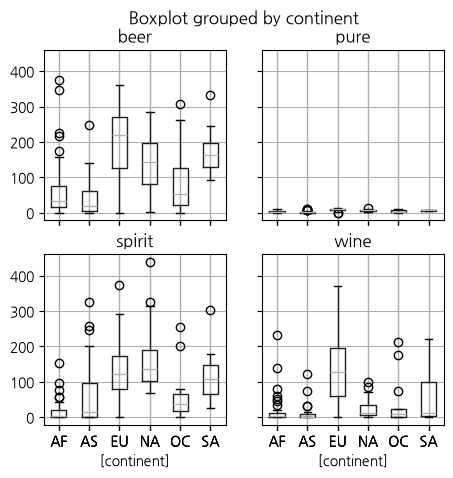

In [37]:
# box plot of all numeric columns grouped by continent
drinks.boxplot(by='continent', figsize=(5, 5))

## 5. Line plot
Purpose: Showing the trend of a numerical variable over time

In [38]:
# read in the ufo data
url = 'https://raw.githubusercontent.com/justmarkham/DAT8/master/data/ufo.csv'
ufo = pd.read_csv(url)
ufo['Time'] = pd.to_datetime(ufo.Time)
ufo['Year'] = ufo.Time.dt.year
ufo

,City,Colors Reported,Shape Reported,State,Time,Year
0,Ithaca,NaN,TRIANGLE,NY,1930-06-01 22:00:00,1930
1,Willingboro,NaN,OTHER,NJ,1930-06-30 20:00:00,1930
2,Holyoke,NaN,OVAL,CO,1931-02-15 14:00:00,1931
3,Abilene,NaN,DISK,KS,1931-06-01 13:00:00,1931
4,New York Worlds Fair,NaN,LIGHT,NY,1933-04-18 19:00:00,1933
...,...,...,...,...,...,...
80538,Neligh,NaN,CIRCLE,NE,2014-09-04 23:20:00,2014
80539,Uhrichsville,NaN,LIGHT,OH,2014-09-05 01:14:00,2014
80540,Tucson,RED BLUE,NaN,AZ,2014-09-05 02:40:00,2014
80541,Orland park,RED,LIGHT,IL,2014-09-05 03:43:00,2014


In [39]:
ufo.dtypes

City                          str
Colors Reported               str
Shape Reported                str
State                         str
Time               datetime64[us]
Year                        int32
dtype: object

In [40]:
# count the number of ufo reports each year (and sort by year)
ufo.Year.value_counts().sort_index()

Year
1930       2
1931       2
1933       1
1934       1
1935       1
        ... 
2010    4154
2011    5089
2012    7263
2013    7003
2014    5382
Name: count, Length: 82, dtype: int64

<Axes: xlabel='Year'>

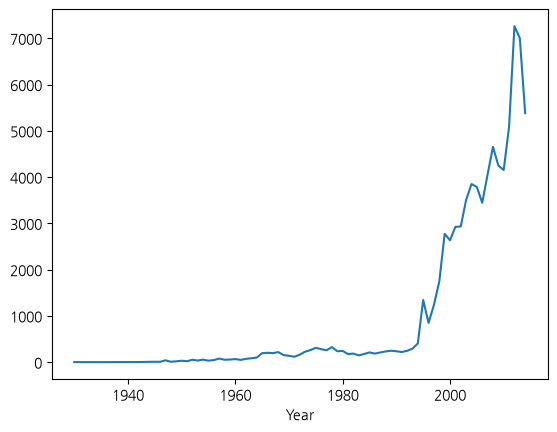

In [41]:
# compare with line plot
ufo.Year.value_counts().sort_index().plot()

## 6. Saving a plot and Changing a style

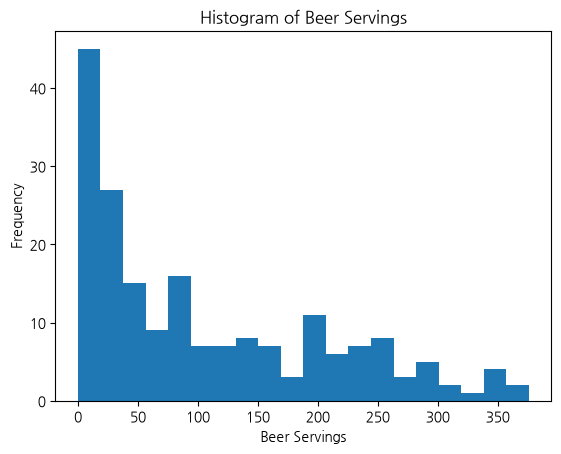

In [42]:
# saving a plot to a file
drinks.beer.plot(kind='hist', bins=20, title='Histogram of Beer Servings')
plt.xlabel('Beer Servings')
plt.ylabel('Frequency')
plt.savefig('image/beer_histogram_original.png')

In [43]:
# list available plot styles
plt.style.available

['Solarize_Light2',
 'bmh',
 'classic',
 'dark_background',
 'fast',
 'fivethirtyeight',
 'ggplot',
 'grayscale',
 'petroff10',
 'petroff6',
 'petroff8',
 'seaborn-v0_8',
 'seaborn-v0_8-bright',
 'seaborn-v0_8-colorblind',
 'seaborn-v0_8-dark',
 'seaborn-v0_8-dark-palette',
 'seaborn-v0_8-darkgrid',
 'seaborn-v0_8-deep',
 'seaborn-v0_8-muted',
 'seaborn-v0_8-notebook',
 'seaborn-v0_8-paper',
 'seaborn-v0_8-pastel',
 'seaborn-v0_8-poster',
 'seaborn-v0_8-talk',
 'seaborn-v0_8-ticks',
 'seaborn-v0_8-white',
 'seaborn-v0_8-whitegrid',
 'tableau-colorblind10']

In [44]:
# change to a different style
plt.style.use('ggplot')

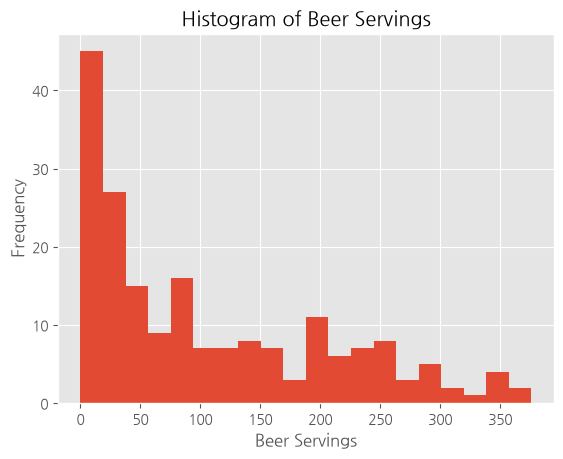

In [45]:
# saving a plot to a file
drinks.beer.plot(kind='hist', bins=20, title='Histogram of Beer Servings')
plt.xlabel('Beer Servings')
plt.ylabel('Frequency')
plt.savefig('image/beer_histogram_ggplot.png')

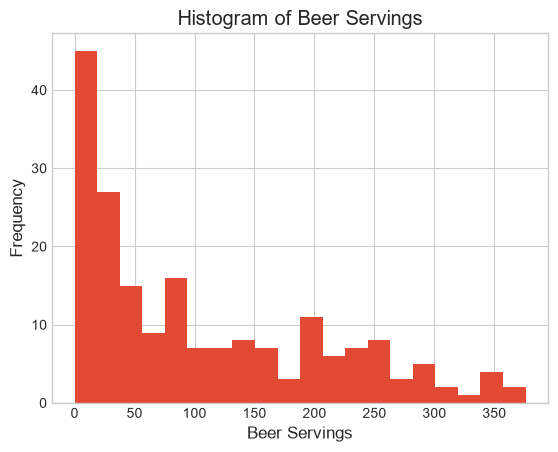

In [46]:
# Other example
plt.style.use('seaborn-v0_8-whitegrid')
drinks.beer.plot(kind='hist', bins=20, title='Histogram of Beer Servings')
plt.xlabel('Beer Servings')
plt.ylabel('Frequency')
plt.savefig('image/beer_histogram_seaborn.png')

# 7. Style


**Marker**:
- http://matplotlib.org/1.5.1/examples/lines_bars_and_markers/marker_reference.html
- http://matplotlib.org/api/markers_api.html

**Line**:
- http://matplotlib.org/1.5.1/examples/lines_bars_and_markers/line_styles_reference.html
- http://matplotlib.org/api/lines_api.html

**Color**:
- http://matplotlib.org/examples/color/named_colors.html
- http://matplotlib.org/api/colors_api.html


In [47]:
from IPython.display import Image

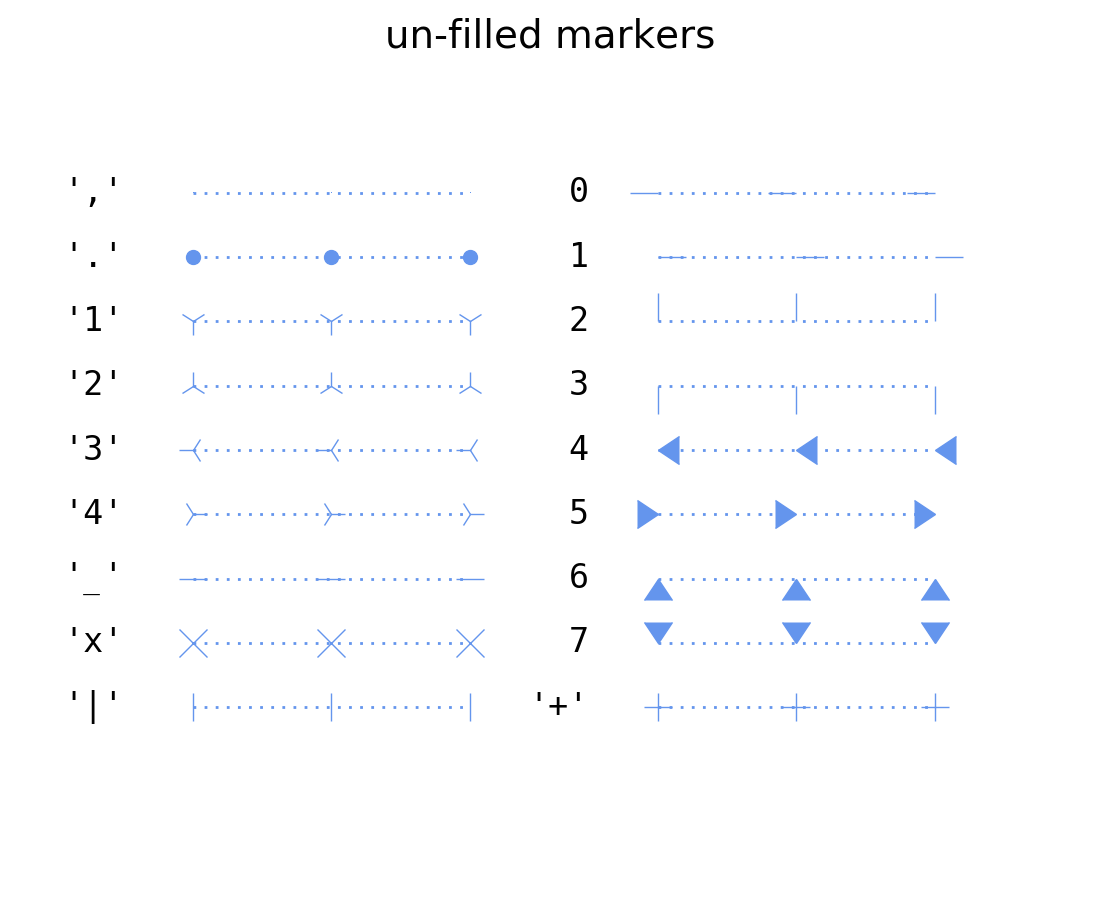

In [48]:
Image(filename="image/marker_reference_00.png")

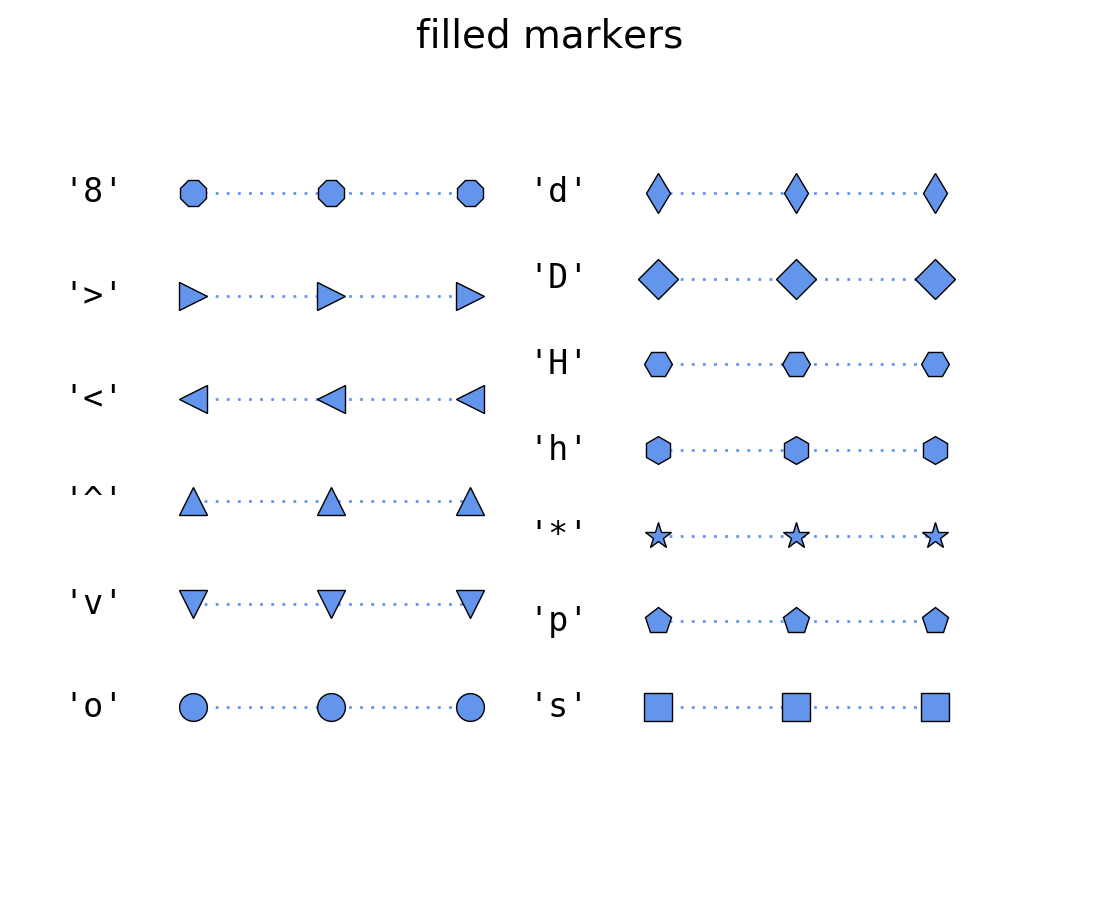

In [49]:
Image(filename="image/marker_reference_01.png")

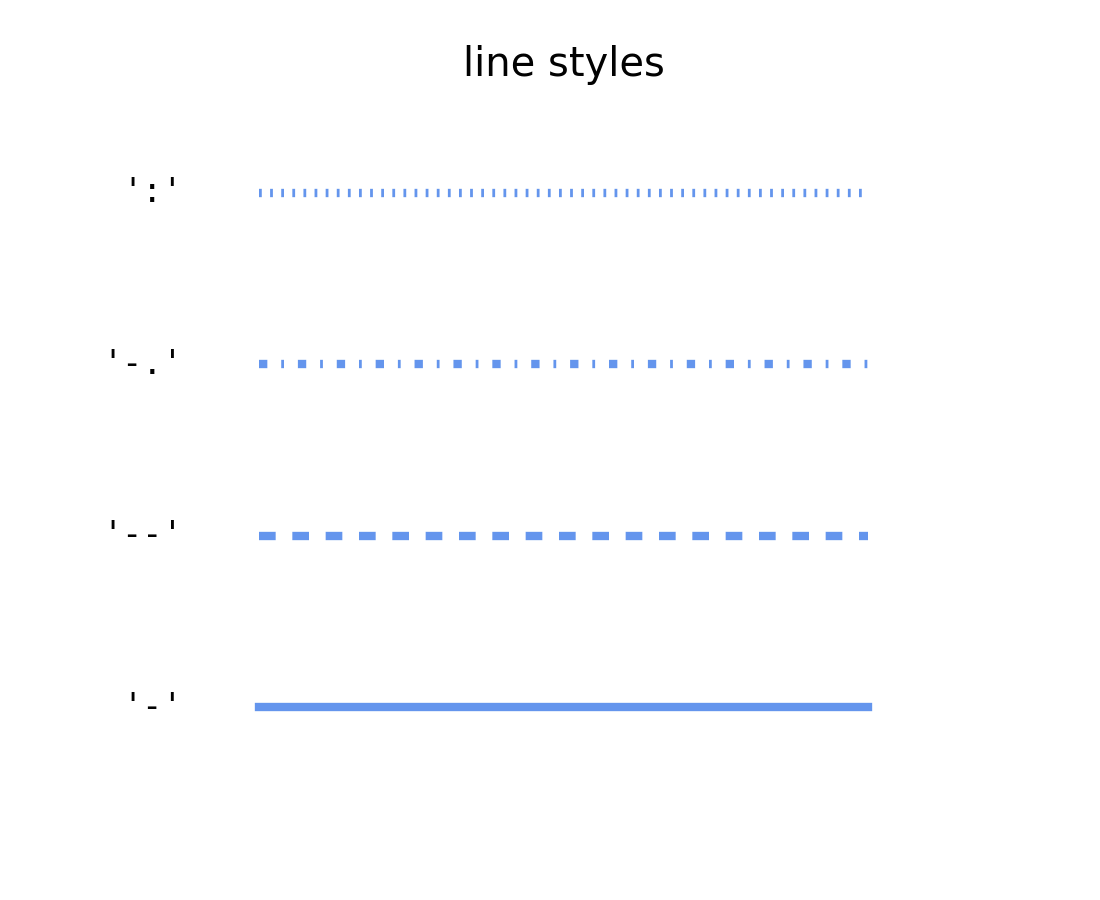

In [50]:
Image(filename="image/line_styles_reference.png")

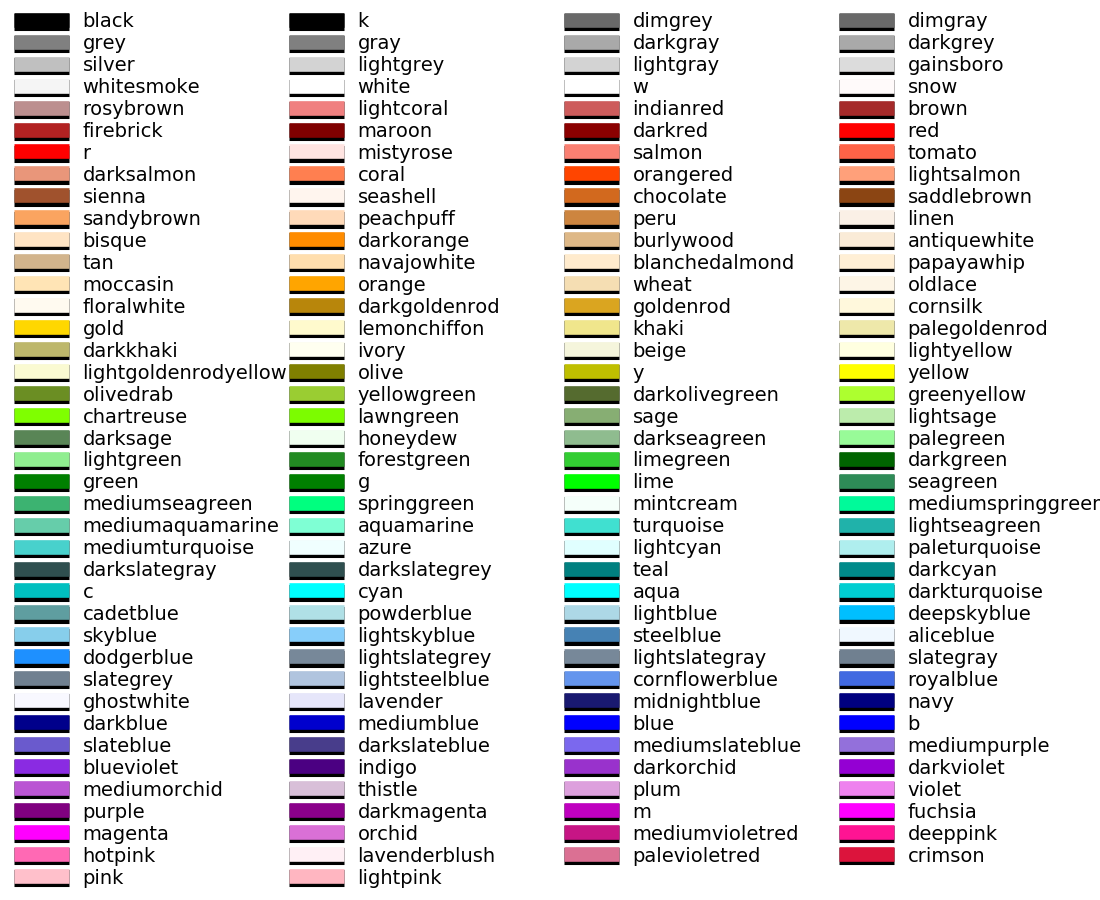

In [51]:
Image(filename="image/named_colors.png")

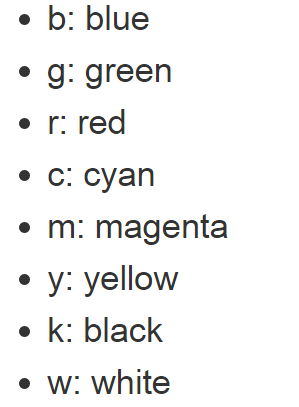

In [52]:
Image(filename="image/named_colors_brief.png")